# Versao 8 - Pre-processamento

## Objetivo deste notebook

Agora que ja entendemos a base, precisamos preparar os dados para classificacao. Esse notebook e um dos mais importantes para um aluno iniciante, porque ele mostra como sair de **arquivos com series de comprimentos diferentes** para **matrizes numéricas prontas para o treinamento**.

## Ideia central do pre-processamento

Vamos seguir o fluxo abaixo:

1. construir um `manifest` com todos os arquivos;
2. fazer `split` estratificado em treino, validacao e teste;
3. selecionar colunas realmente informativas;
4. reamostrar cada serie para o mesmo comprimento;
5. padronizar os sinais;
6. gerar duas representacoes:
   - `X_seq`: sequencias para a `LSTM`;
   - `X_tab`: estatisticas agregadas para `RandomForest` e `XGBoost`.

Essa separacao e didaticamente excelente porque mostra que o mesmo problema pode ser atacado por duas familias de modelos:

- modelos sequenciais;
- modelos tabulares/classicos.

Na `versao8`, damos um passo adicional: parte importante desse pre-processamento fica explicitamente escrita no proprio notebook, para que o professor consiga acompanhar a transformacao das series sem precisar abrir o pipeline completo.

## Artefatos Da Ultima Execucao

A execucao registrada em `artifacts/reports_v8/classificacao_v8_explicita/` consolidou o seguinte desenho experimental:

- amostras por split: `train = 1559`, `validation = 334`, `test = 335`
- colunas selecionadas para modelagem: `18`
- colunas continuas: `9`
- colunas de estado discreto: `9`
- comprimento fixo das sequencias: `120`
- numero total de atributos em `X_tab`: `162`
- exemplo do desbalanceamento que permanece apos o split: classe `0` com `416` amostras no treino e classe `2` com apenas `27`

Em termos metodologicos, isso significa que a `LSTM` recebe tensores no formato `(N, 120, 18)`, enquanto as baselines tabulares recebem vetores com `162` descritores agregados por amostra. Essa assimetria de representacao ajuda a explicar por que `RandomForest` e `XGBoost` continuam tao competitivos no projeto.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Este bloco torna o notebook robusto ao diretorio atual.
# Se o notebook estiver sendo executado de dentro de `versao8`,
# o projeto real estara um nivel acima.
ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao8" else ROOT

# Adicionamos a raiz do projeto ao sys.path para conseguir importar
# `versao8.pipeline_v8` e demais modulos auxiliares.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
from versao8.pipeline_v8 import (
    BASE_TARGET_COLUMNS,
    load_bundle,
    load_split_arrays,
    prepare_classification_artifacts,
    clean_base_frame,
)

# Parametros principais do experimento.
DATASET_ROOT = PROJECT_ROOT / "3W" / "dataset"
RUN_NAME = "classificacao_v8_explicita"
SEQUENCE_LENGTH = 120
TRAIN_FRAC = 0.70
VALIDATION_FRAC = 0.15
RANDOM_STATE = 42

## Bloco explicito de pre-processamento

O proposito das celulas abaixo e pedagogico: mostrar, no proprio notebook, como a serie e reamostrada e como o vetor tabular de estatisticas e construido. Essas definicoes repetem a logica do pipeline, mas agora ficam visiveis para inspeção detalhada.

In [3]:
# ================================
# BLOCO DIDATICO DE PRE-PROCESSAMENTO
# ================================
# Este bloco replica, de forma visivel no notebook, as etapas centrais
# do pre-processamento que antes estavam mais escondidas dentro do pipeline.
# A ideia nao e substituir todo o pipeline, mas explicitar para o professor
# como a serie e transformada em:
# 1) uma sequencia de comprimento fixo para a LSTM
# 2) um vetor de atributos estatisticos para as baselines tabulares

SERIES_STAT_NAMES_VISIBLE = [
    "mean",
    "std",
    "min",
    "max",
    "median",
    "first",
    "last",
    "slope",
    "mean_abs_diff",
]


def _safe_numeric_matrix_visible(values: np.ndarray, clip_abs: float = 1e12) -> np.ndarray:
    # Garantimos uma matriz numerica finita para evitar problemas de escala.
    matrix = np.asarray(values, dtype=np.float64)
    matrix = np.clip(matrix, -clip_abs, clip_abs)
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    return matrix


def resample_frame_to_fixed_length_visible(
    frame: pd.DataFrame,
    feature_columns: list[str],
    sequence_length: int,
    state_columns: list[str] | None = None,
) -> np.ndarray:
    # Esta e uma das funcoes mais importantes do projeto.
    # Ela faz todas as series passarem a ter o mesmo numero de passos temporais.
    state_columns = state_columns or []

    if sequence_length <= 0:
        raise ValueError("sequence_length precisa ser maior que zero.")
    if len(frame) == 0:
        raise ValueError("A serie nao pode estar vazia.")

    if len(frame) == 1:
        # Se a serie tiver apenas um passo, repetimos esse valor ate o comprimento desejado.
        single_row = _safe_numeric_matrix_visible(frame[feature_columns].to_numpy(dtype=np.float64))
        return np.repeat(single_row, repeats=sequence_length, axis=0)

    source_pos = np.linspace(0.0, 1.0, len(frame), dtype=np.float64)
    target_pos = np.linspace(0.0, 1.0, sequence_length, dtype=np.float64)

    columns_resampled = []
    for column in feature_columns:
        values = pd.to_numeric(frame[column], errors="coerce").to_numpy(dtype=np.float64)

        if column in state_columns:
            # Para estados discretos, preferimos o vizinho mais proximo
            # em vez de interpolar valores fracionarios sem sentido fisico.
            interpolated_idx = np.interp(target_pos, source_pos, np.arange(len(frame), dtype=np.float64))
            nearest_idx = np.rint(interpolated_idx).astype(np.int64)
            nearest_idx = np.clip(nearest_idx, 0, len(frame) - 1)
            resampled = values[nearest_idx]
        else:
            # Para sinais continuos, usamos interpolacao linear.
            resampled = np.interp(target_pos, source_pos, values)

        columns_resampled.append(resampled)

    return _safe_numeric_matrix_visible(np.stack(columns_resampled, axis=1))


def compute_statistical_feature_vector_visible(
    sequence_array: np.ndarray,
    feature_columns: list[str],
) -> np.ndarray:
    # Este vetor sintetiza a serie para os modelos tabulares.
    # Cada coluna gera 9 descritores estatisticos.
    sequence = np.asarray(sequence_array, dtype=np.float64)
    if sequence.ndim != 2:
        raise ValueError("A sequencia precisa ter duas dimensoes: [tempo, features].")

    time_axis = np.arange(sequence.shape[0], dtype=np.float64)
    feature_values = []

    for feature_idx, _ in enumerate(feature_columns):
        values = sequence[:, feature_idx]
        if len(values) > 1:
            slope = float(np.polyfit(time_axis, values, deg=1)[0])
            mean_abs_diff = float(np.abs(np.diff(values)).mean())
        else:
            slope = 0.0
            mean_abs_diff = 0.0

        feature_values.extend(
            [
                float(values.mean()),
                float(values.std()),
                float(values.min()),
                float(values.max()),
                float(np.median(values)),
                float(values[0]),
                float(values[-1]),
                slope,
                mean_abs_diff,
            ]
        )

    return np.asarray(feature_values, dtype=np.float32)

## Geracao dos artefatos

A chamada abaixo cria toda a estrutura reutilizavel da versao8. Ela salva:

- `manifest` com o split;
- `bundle` com as decisoes de preprocessamento;
- relatorio de selecao de colunas;
- arrays `npz` de treino, validacao e teste;
- metadados auxiliares de cada split.

Se voce estiver executando pela primeira vez, essa e a principal celula a rodar neste notebook.

In [4]:
artifacts = prepare_classification_artifacts(
    dataset_root=DATASET_ROOT,
    run_name=RUN_NAME,
    train_frac=TRAIN_FRAC,
    validation_frac=VALIDATION_FRAC,
    random_state=RANDOM_STATE,
    sequence_length=SEQUENCE_LENGTH,
)

artifacts

PreparedClassificationArtifacts(run_dir='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v8/classificacao_v8_explicita', bundle_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v8/classificacao_v8_explicita/bundle_v8.json', manifest_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v8/classificacao_v8_explicita/split_manifest_v6.csv', attribute_catalog_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v8/classificacao_v8_explicita/catalogo_atributos.csv', event_catalog_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v8/classificacao_v8_explicita/catalogo_eventos.csv', feature_selection_report_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v8/classificacao_v8_explicita/relatorio_selecao_de_features.csv', split_npz_paths={'train': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v8/classificacao_v8_explicita/train_arrays.npz', 'validation': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v8/classificacao_v

In [5]:
# Carregamos o bundle salvo para inspecionar o que o pipeline decidiu.
bundle = load_bundle(artifacts.bundle_path)

# O bundle e o "contrato" do pre-processamento:
# ele diz quais colunas foram usadas, qual o comprimento fixo
# das sequencias e quais estatisticas servem para escalonamento.
bundle_summary = pd.DataFrame(
    {
        "campo": [
            "selected_columns",
            "continuous_columns",
            "state_columns",
            "sequence_length",
            "class_labels",
            "split_counts",
        ],
        "valor": [
            bundle.selected_columns,
            bundle.continuous_columns,
            bundle.state_columns,
            bundle.sequence_length,
            bundle.class_labels,
            bundle.split_counts,
        ],
    }
)
display(bundle_summary)

# Relatorio de selecao de features.
feature_report = pd.read_csv(artifacts.feature_selection_report_path)
display(feature_report)

,campo,valor
0,selected_columns,"[ESTADO-DHSV, ESTADO-M1, ESTADO-M2, ESTADO-PXO..."
1,continuous_columns,"[P-ANULAR, P-JUS-CKGL, P-MON-CKP, P-PDG, P-TPT..."
2,state_columns,"[ESTADO-DHSV, ESTADO-M1, ESTADO-M2, ESTADO-PXO..."
3,sequence_length,120
4,class_labels,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
5,split_counts,"{'test': 335, 'train': 1559, 'validation': 334}"


,column,column_type,null_pct,nunique,std,selected_for_modeling
0,ESTADO-DHSV,state,0.0,2,3.108289e-01,True
1,ESTADO-M1,state,0.0,2,4.188562e-01,True
2,ESTADO-M2,state,0.0,2,2.502220e-01,True
3,ESTADO-PXO,state,0.0,2,2.373703e-02,True
4,ESTADO-SDV-GL,state,0.0,2,2.933506e-01,True
5,ESTADO-SDV-P,state,0.0,2,4.529911e-01,True
6,ESTADO-W1,state,0.0,2,4.301969e-01,True
7,ESTADO-W2,state,0.0,3,1.939657e-01,True
8,ESTADO-XO,state,0.0,2,2.647794e-02,True
9,P-ANULAR,main_signal,0.0,58797,8.214054e+06,True


In [6]:
# Agora abrimos os arrays que serao usados pelos modelos.
train_arrays = load_split_arrays(artifacts.split_npz_paths["train"])
val_arrays = load_split_arrays(artifacts.split_npz_paths["validation"])
test_arrays = load_split_arrays(artifacts.split_npz_paths["test"])

shape_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "X_seq_shape": [
            train_arrays["X_seq"].shape,
            val_arrays["X_seq"].shape,
            test_arrays["X_seq"].shape,
        ],
        "X_tab_shape": [
            train_arrays["X_tab"].shape,
            val_arrays["X_tab"].shape,
            test_arrays["X_tab"].shape,
        ],
        "y_shape": [
            train_arrays["y"].shape,
            val_arrays["y"].shape,
            test_arrays["y"].shape,
        ],
    }
)
shape_summary

,split,X_seq_shape,X_tab_shape,y_shape
0,train,"(1559, 120, 18)","(1559, 162)","(1559,)"
1,validation,"(334, 120, 18)","(334, 162)","(334,)"
2,test,"(335, 120, 18)","(335, 162)","(335,)"


## Leitura quantitativa do pre-processamento

Para um aluno iniciante, esta parte merece uma pausa. O pre-processamento gerou, ao mesmo tempo, uma representacao sequencial e uma representacao tabular do mesmo problema.

Em termos praticos:

- `X_seq` preserva a ordem temporal e sera usado pela `LSTM`;
- `X_tab` resume cada serie em estatisticas agregadas e sera usado pelas baselines;
- o mesmo vetor `y` continua representando a classe da amostra.

Esse desenho experimental e muito valioso porque nos permite comparar, de forma justa, dois paradigmas:

- aprendizado sequencial profundo;
- aprendizado supervisionado classico sobre atributos sinteticos.

In [7]:
# Esta tabela ajuda a enxergar a escala do problema de forma objetiva.
feature_family_summary = pd.DataFrame(
    {
        "item": [
            "numero de colunas selecionadas",
            "colunas continuas",
            "colunas de estado discreto",
            "comprimento fixo da sequencia",
            "atributos tabulares agregados",
            "amostras de treino",
            "amostras de validacao",
            "amostras de teste",
        ],
        "valor": [
            len(bundle.selected_columns),
            len(bundle.continuous_columns),
            len(bundle.state_columns),
            bundle.sequence_length,
            len(bundle.statistical_feature_names),
            len(train_arrays["y"]),
            len(val_arrays["y"]),
            len(test_arrays["y"]),
        ],
    }
)
display(feature_family_summary)

# Tambem abrimos a distribuicao de classes por split.
split_distribution_rows = []
for split_name, arrays in {
    "train": train_arrays,
    "validation": val_arrays,
    "test": test_arrays,
}.items():
    counts = pd.Series(arrays["y"]).value_counts().sort_index()
    for class_label, count in counts.items():
        split_distribution_rows.append(
            {
                "split": split_name,
                "classe": int(class_label),
                "amostras": int(count),
                "proporcao_no_split": float(count / len(arrays["y"])),
            }
        )

split_distribution_df = pd.DataFrame(split_distribution_rows)
display(split_distribution_df)

,item,valor
0,numero de colunas selecionadas,18
1,colunas continuas,9
2,colunas de estado discreto,9
3,comprimento fixo da sequencia,120
4,atributos tabulares agregados,162
5,amostras de treino,1559
6,amostras de validacao,334
7,amostras de teste,335


,split,classe,amostras,proporcao_no_split
0,train,0,416,0.266838
1,train,1,89,0.057088
2,train,2,27,0.017319
3,train,3,74,0.047466
4,train,4,240,0.153945
5,train,5,315,0.202053
6,train,6,155,0.099423
7,train,7,32,0.020526
8,train,8,66,0.042335
9,train,9,145,0.093008


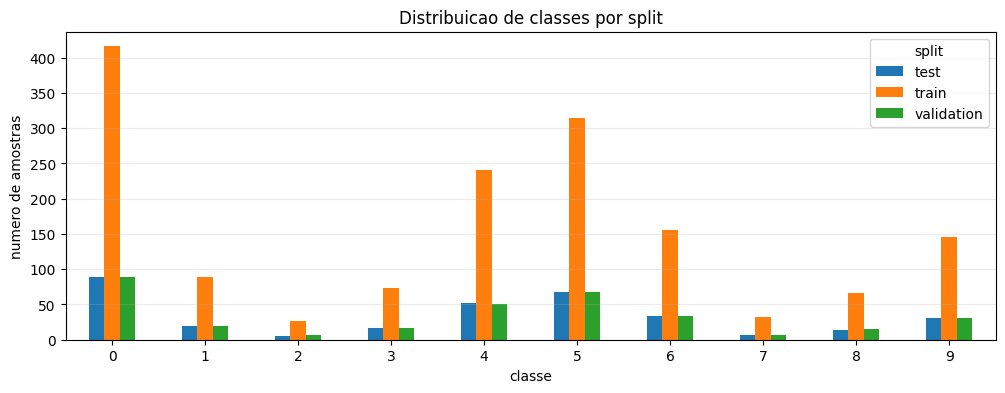

In [8]:
# Um grafico por barras facilita a leitura do desbalanceamento
# dentro de cada subconjunto.
pivot_counts = split_distribution_df.pivot(index="classe", columns="split", values="amostras").fillna(0)
pivot_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Distribuicao de classes por split")
plt.xlabel("classe")
plt.ylabel("numero de amostras")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.show()

## Entendendo o que aconteceu com uma serie real

Uma das etapas mais importantes aqui e a **reamostragem para comprimento fixo**. Como as series do `3W` possuem duracoes diferentes, a `LSTM` precisa receber um tensor de formato padronizado:

```text
(numero_de_amostras, comprimento_fixado, numero_de_features)
```

Isso nao destrói a serie, mas faz uma **normalizacao do eixo temporal**: cada amostra passa a ser representada com o mesmo numero de passos.

In [9]:
# Escolhemos uma amostra real de treino para enxergar
# o efeito da reamostragem.
train_metadata = pd.read_csv(artifacts.split_metadata_paths["train"])
example_row = train_metadata.iloc[0]

example_frame = clean_base_frame(
    example_row["file_path"],
    target_columns=BASE_TARGET_COLUMNS,
    candidate_auxiliary_columns=[c for c in bundle.selected_columns if c not in BASE_TARGET_COLUMNS],
)

example_resampled = resample_frame_to_fixed_length_visible(
    example_frame,
    feature_columns=bundle.selected_columns,
    sequence_length=bundle.sequence_length,
    state_columns=bundle.state_columns,
)

print("Shape original da serie:", example_frame[bundle.selected_columns].shape)
print("Shape apos reamostragem:", example_resampled.shape)

Shape original da serie: (21474, 18)
Shape apos reamostragem: (120, 18)


In [10]:
# Agora mostramos explicitamente a construcao do vetor tabular.
example_stat_vector = compute_statistical_feature_vector_visible(
    example_resampled,
    bundle.selected_columns,
)

print("Numero de descritores estatisticos produzidos:", len(example_stat_vector))
print("Primeiros 18 valores do vetor tabular:")
print(example_stat_vector[:18])

Numero de descritores estatisticos produzidos: 162
Primeiros 18 valores do vetor tabular:
[1.0000000e+00 0.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.5133257e-18 0.0000000e+00 1.0000000e+00
 0.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.5133257e-18 0.0000000e+00]


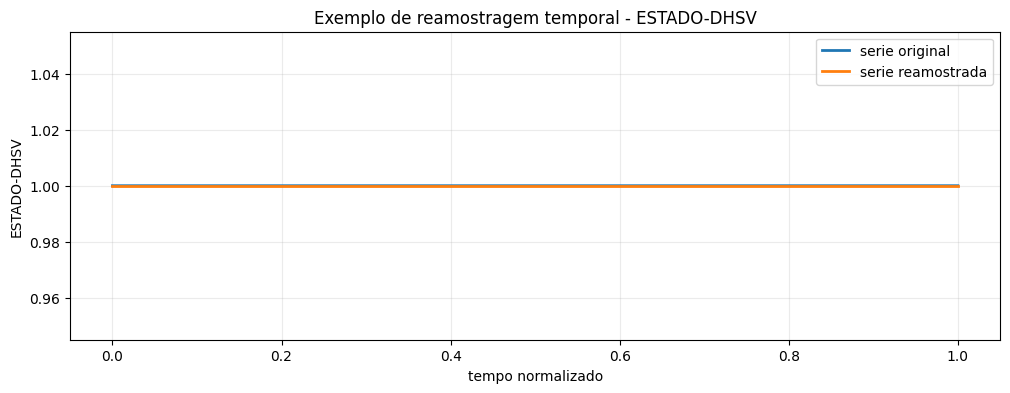

In [11]:
# Comparamos uma variavel original e a mesma variavel apos reamostragem.
# Isso ajuda a entender visualmente o que significa "fixar o comprimento".
signal_name = bundle.selected_columns[0]

plt.figure(figsize=(12, 4))
plt.plot(
    np.linspace(0, 1, len(example_frame)),
    example_frame[signal_name].to_numpy(),
    label="serie original",
    linewidth=2,
)
plt.plot(
    np.linspace(0, 1, bundle.sequence_length),
    example_resampled[:, 0],
    label="serie reamostrada",
    linewidth=2,
)
plt.title(f"Exemplo de reamostragem temporal - {signal_name}")
plt.xlabel("tempo normalizado")
plt.ylabel(signal_name)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## O que aprendemos com os numeros deste notebook

O pre-processamento mostra algo conceitualmente importante:

- o problema continua desbalanceado, mesmo apos o `split` estratificado;
- a `LSTM` vera tensores de forma `(N, 120, 18)`;
- a baseline tabular recebera `162` descritores estatisticos por amostra.

Esse ultimo ponto e especialmente relevante. Quando uma baseline tabular recebe muitos descritores agregados informativos, ela pode se tornar muito competitiva. Por isso, desde ja, este notebook prepara o terreno para uma comparacao metodologicamente justa com a `LSTM`.

## Fechamento do notebook

Ao final deste notebook, os dados ja estao prontos em dois formatos:

- `X_seq`: para a `LSTM`;
- `X_tab`: para os classificadores baseados em features agregadas.

Nos proximos notebooks, vamos explorar exatamente essas duas familias de modelos.